The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\Users\Martin\Active\otp-sizing\otp\pump\analysis.py:129: RuntimeWarning: divide by zero encountered in scalar divide
  specific_speed = rpm * np.sqrt(Q) / (H_total_real)**0.75


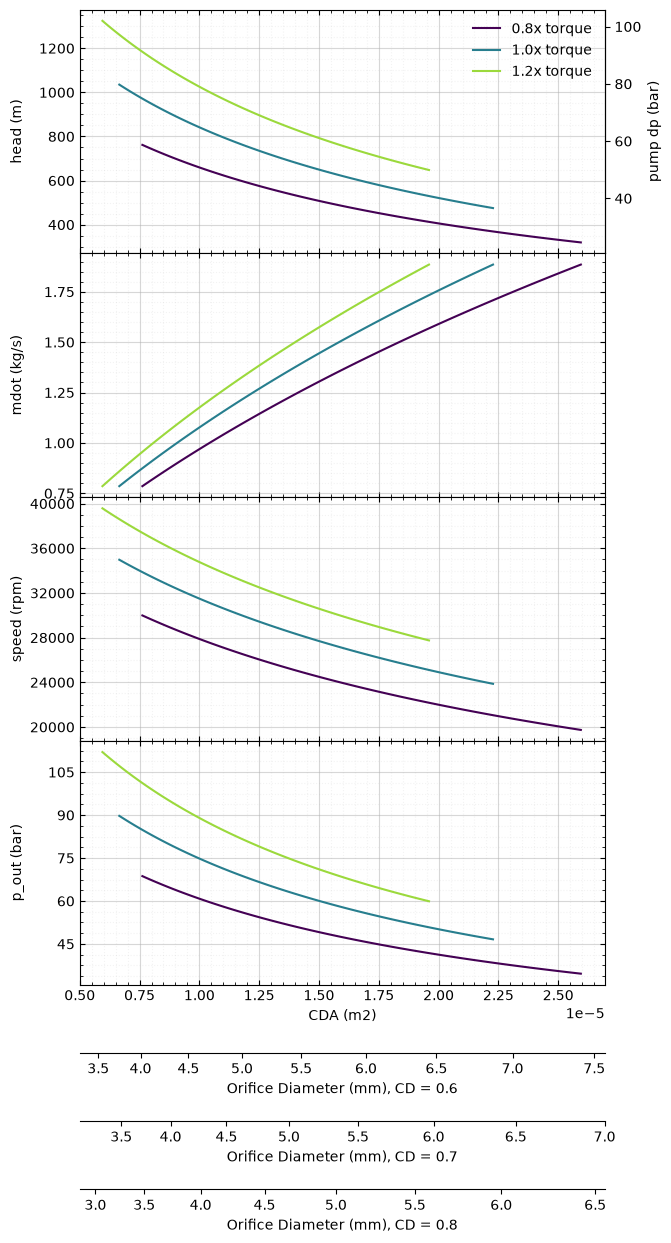

In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

from data.OT2.ot2 import PUMP
from otp.core.units import BAR, K_TO_C, P_A, g
from otp.propellants.propellant import Propellant
from pyfluids import FluidsList, Input
from otp.experiments.loaders.airborne import load_run
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt

T_K = 293.15
P_IN = 10 * BAR

def rho(fl):
    return fl.fluid.with_state(Input.pressure(1 * BAR), Input.temperature(T_K + K_TO_C)).density

WATER = Propellant("Water", FluidsList.Water, t_tank=T_K, p_tank=P_IN)
class IPA:                      # CoolProp has no propan-2-ol; 20 C literature values
    class _s: density, kinematic_viscosity, pressure = 785.4, 2.66e-6, 4400.0
    class fluid:
        with_state = staticmethod(lambda *a: IPA._s)   # .pressure only read for p_sat

from data.OT2.ot2 import CHANNEL_MAP, DATA_PATH
run = load_run(DATA_PATH, cmap=CHANNEL_MAP)
STEADY_STATE_START, STEADY_STATE_END = (5.0, 10.0)


def get_test_torque_head_flow_rpm():
    CD = 0.71
    D_OR = 0.004
    A = np.pi * D_OR**2 / 4

    n = run["rpm"].mean(STEADY_STATE_START, STEADY_STATE_END)
    p_in = run["p_pump_in"].mean(STEADY_STATE_START, STEADY_STATE_END) * BAR
    dp = run["dp_pump"].mean(STEADY_STATE_START, STEADY_STATE_END) * BAR
    head = dp / (rho(WATER) * 9.81)

    f = lambda Q: CD * A * np.sqrt(2 * max(PUMP.point_performance(WATER, Q, n, p_in, T_K, "lock").p_outlet - P_A, 0) / rho(WATER)) - Q

    solved_Q = brentq(f, 1e-7, 1e-2)
    return PUMP.point_performance(WATER, solved_Q, n, p_in, T_K, "lock").torque, head, solved_Q, n

TEST_TORQUE, TEST_HEAD, TEST_FLOW, TEST_RPM = get_test_torque_head_flow_rpm()
TEST_CDA = 0.71 * 0.004**2 / 4 * np.pi

def head_at_flow_torque(fl, flowrate, torque):
    f = lambda rpm: PUMP.point_performance(fl, flowrate, rpm, P_IN, T_K, "lock").torque - torque
    try:
        solved_rpm = brentq(f, 10000, 50000)
        solved_perf = PUMP.point_performance(fl, flowrate, solved_rpm, P_IN, T_K, "lock")
        return solved_perf
    except:
        return None
    

FLOWRATES = np.linspace(1e-3, 2.4e-3, 100)
CASES = {
            0: {"label": "0.8x torque", "torque_mult": 0.8, "color_index": 0, "linestyle": "-"},
            1: {"label": "1.0x torque", "torque_mult": 1.0, "color_index": 1, "linestyle": "-"},
            2: {"label": "1.2x torque", "torque_mult": 1.2, "color_index": 2, "linestyle": "-"}}
colors = plt.get_cmap(plt.cm.viridis)(np.linspace(0, 0.85, 3))

fig, [ax0, ax1, ax2, ax3] = plt.subplots(4, 1, figsize=(7, 13), sharex=True)

def cda_to_d(cd):
    return lambda cda: 1e3 * np.sqrt(4 * np.clip(cda, 0, None) / (cd * np.pi))

def d_to_cda(cd):
    return lambda d: cd * np.pi / 4 * (np.asarray(d) / 1e3) ** 2

# ax0.plot(TEST_CDA, TEST_HEAD, "x", label="Test data", markersize=10, color="k")
# ax1.plot(TEST_CDA, TEST_FLOW*rho(WATER), "x", label="Test data", markersize=10, color="k")
# ax2.plot(TEST_CDA, TEST_RPM, "x", label="Test data", markersize=10, color="k")

for case in CASES.values():
    label, torque_mult, color_index, linestyle = case.values()
    torque = TEST_TORQUE * torque_mult
    perfs = [head_at_flow_torque(IPA, Q, torque) for Q in FLOWRATES]
    ok = [(Q, p) for Q, p in zip(FLOWRATES, perfs) if p is not None and p.p_outlet > P_A]
    cdas = np.array([Q / np.sqrt(2 * (p.p_outlet - P_A) / rho(IPA)) for Q, p in ok])
    head = np.array([p.H_total_real for _, p in ok])
    mdot = np.array([p.mdot for _, p in ok])
    rpm  = np.array([p.rpm for _, p in ok])
    p_out = np.array([p.p_outlet / BAR for _, p in ok])

    kw = dict(label=label, color=colors[color_index], linestyle=linestyle)
    ax0.plot(cdas, head, **kw)
    ax1.plot(cdas, mdot, **kw)
    ax2.plot(cdas, rpm, **kw)
    ax3.plot(cdas, p_out, **kw)

from matplotlib.ticker import MaxNLocator, AutoMinorLocator

# using AI to make the plots nicer

ax0.set_ylabel("head (m)")
ax1.set_ylabel("mdot (kg/s)")
ax2.set_ylabel("speed (rpm)")
ax3.set_ylabel("p_out (bar)")

for ax in (ax0, ax1, ax2, ax3):
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(which="major", alpha=0.5)
    ax.grid(which="minor", alpha=0.15, linestyle=":")
    ax.tick_params(which="both", direction="in", top=True, right=True)

for ax in (ax1, ax2, ax3):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6, prune="upper"))

ax0.tick_params(which="both", right=False)
sec_dp = ax0.secondary_yaxis("right", functions=(lambda h: h * rho(IPA) * g / BAR,
                                                 lambda dp: dp * BAR / (rho(IPA) * g)))

sec_dp.set_ylabel("pump dp (bar)")


ax3.set_xlabel("CDA (m2)")                # was ax2
ax3.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax3.set_xlim(left=0.5e-5)

for loc, cd in ((-0.28, 0.6), (-0.56, 0.7), (-0.84, 0.8)):
    sec = ax3.secondary_xaxis(loc, functions=(cda_to_d(cd), d_to_cda(cd)))  
    sec.set_xlabel(rf"Orifice Diameter (mm), CD = {cd}")
    sec.tick_params(direction="out")

ax0.legend(loc="best", frameon=False)
fig.align_ylabels((ax0, ax1, ax2, ax3))
fig.subplots_adjust(hspace=0, left=0.13, right=0.88, top=0.95, bottom=0.2)
plt.show()



In [5]:
0.7 * 0.01**2 / 4 * np.pi

5.497787143782138e-05